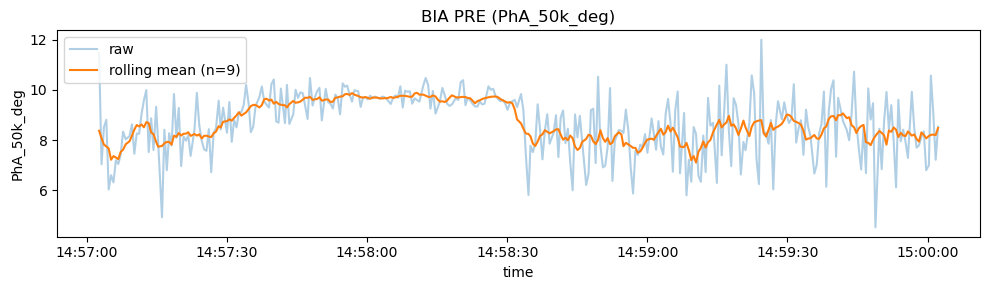

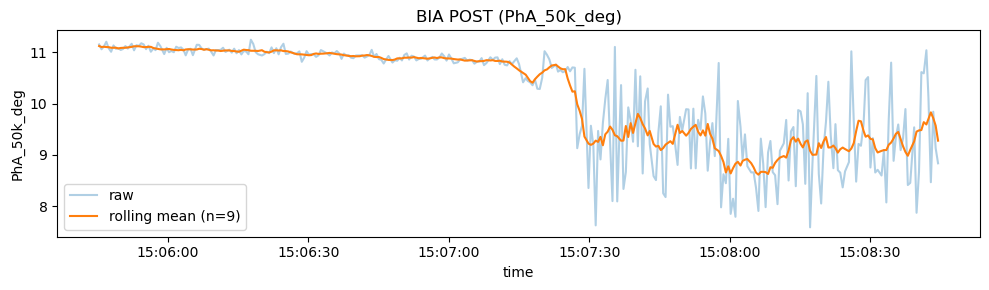


VARIABLES À UTILISER
- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)
- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)
- pha_pre   : numpy array, PhA_50k_deg sur PRE
- pha_post  : numpy array, PhA_50k_deg sur POST
- t_pre     : numpy array, temps (s) relatif au début de PRE
- t_post    : numpy array, temps (s) relatif au début de POST
- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)
- fs_post_est : float, fs approx POST (= 1 / dt_médian)


In [5]:

# BIA RAW IMPORT -> PhA_50k -> PRE/POST WINDOWS -> OUTPUT VARS
# RAW, NO FILTERING / NO RESAMPLING IMPOSED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG 

BIA_PKL_PATH = "../data/LEA_BIA_RAW.pkl"   # pkl file exported from BIA device (raw data for pandas)
FREQ_COL = "f_48800"              # ~50 kHz complex impedance column

# Window timestamps (BIA datetime): 3 minutes BEFORE / fatigue inducing protocole / and 3 minutes AFTER
PRE_START_TIME  = "2025-11-28 14:57:02.563"
PRE_END_TIME    = "2025-11-28 15:00:02.563"
POST_START_TIME = "2025-11-28 15:05:45.278"
POST_END_TIME   = "2025-11-28 15:08:44.534"


# LOAD RAW BIA (.pkl)
data_bia_raw = pd.read_pickle(BIA_PKL_PATH)


# ANALYSIS DATAFRAME (same data, cleaner columns)
data_bia = data_bia_raw.copy()

# Parse time
data_bia["time"] = pd.to_datetime(data_bia["timestamp"], errors="coerce")
data_bia = data_bia.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Complex impedance at ~50 kHz
data_bia["Z_50k"] = data_bia[FREQ_COL].astype(np.complex128)

# Compute R, Xc, PhA (standard convention: Xc = -imag(Z))
data_bia["R_50k_ohm"]   = np.real(data_bia["Z_50k"])
data_bia["Xc_50k_ohm"]  = -np.imag(data_bia["Z_50k"])
data_bia["PhA_50k_deg"] = np.degrees(np.arctan2(data_bia["Xc_50k_ohm"], data_bia["R_50k_ohm"]))

# Compact analysis view
analysis_cols = ["time", "Z_50k", "R_50k_ohm", "Xc_50k_ohm", "PhA_50k_deg", "sat", "min", "max"]
data_bia_analysis = data_bia[analysis_cols].copy()

# CREATE WINDOWS (PRE / POST)

pre_start  = pd.to_datetime(PRE_START_TIME)
pre_end    = pd.to_datetime(PRE_END_TIME)
post_start = pd.to_datetime(POST_START_TIME)
post_end   = pd.to_datetime(POST_END_TIME)

def slice_window(df, t0, t1):
    m = (df["time"] >= t0) & (df["time"] <= t1)  # inclusive bounds [start, end]
    return df.loc[m].copy()

bia_pre  = slice_window(data_bia_analysis, pre_start, pre_end)
bia_post = slice_window(data_bia_analysis, post_start, post_end)


#  PLOTS (just for verification)

def plot_window(df_win, title, y_col="PhA_50k_deg", smooth_n=9):
    if len(df_win) < 5:
        print("Not enough points to plot:", title)
        return
    d = df_win.copy()
    d["time"] = pd.to_datetime(d["time"])
    d = d.sort_values("time")
    y = pd.to_numeric(d[y_col], errors="coerce")
    y_sm = y.rolling(smooth_n, center=True, min_periods=1).mean()

    plt.figure(figsize=(10,3))
    plt.plot(d["time"], y, alpha=0.35, label="raw")
    plt.plot(d["time"], y_sm, label=f"rolling mean (n={smooth_n})")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_window(bia_pre,  "BIA PRE (PhA_50k_deg)")
plot_window(bia_post, "BIA POST (PhA_50k_deg)")


# OUTPUT (variables to use)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()

t_pre  = (bia_pre["time"]  - bia_pre["time"].iloc[0]).dt.total_seconds().to_numpy()
t_post = (bia_post["time"] - bia_post["time"].iloc[0]).dt.total_seconds().to_numpy()

dt_pre_med  = float(bia_pre["time"].diff().dt.total_seconds().median())
dt_post_med = float(bia_post["time"].diff().dt.total_seconds().median())
fs_pre_est  = 1.0 / dt_pre_med
fs_post_est = 1.0 / dt_post_med

print("\nVARIABLES À UTILISER")
print("- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)")
print("- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)")
print("- pha_pre   : numpy array, PhA_50k_deg sur PRE")
print("- pha_post  : numpy array, PhA_50k_deg sur POST")
print("- t_pre     : numpy array, temps (s) relatif au début de PRE")
print("- t_post    : numpy array, temps (s) relatif au début de POST")
print("- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)")
print("- fs_post_est : float, fs approx POST (= 1 / dt_médian)")

